# Competitors: Bedashing's share among premium substitutes

The third part of the market model (structure in `market_size.ipynb`, catchments in
`catchments.ipynb`). For each lounge we pick the salons a Bedashing customer would realistically
choose instead, and estimate the lounge's **capture** of that premium market.

Data: `data/seed/v3/salons.csv`, `lounge_candidates.csv` and `lounge_search_saturation.csv`
(from `scripts/fetch_salons.py`).

## 1. Design, and why

**Definition.**
1. **Candidates:** women's beauty, hair and nail salons inside the lounge's 15-min catchment.
   Men-only (barbers, "gents", Arabic-named barbers), closed and non-salon places are excluded.
   **Other Bedashing lounges in the catchment are candidates too**, so lounges whose catchments
   overlap split their shared demand.
2. **Premium:** Google prices the salon *expensive* or *very expensive*; where Google has no price
   (most salons), it has at least the catchment's median review count and a rating of at least 4.3.
3. **Substitutes = the most-reviewed premium salons that together hold 60% of the catchment's premium
   reviews** (50% and 70% as sensitivity). So dense catchments get more substitutes and thin ones
   fewer, and every lounge is measured against the same slice of its market.
4. **Recall correction:** where our search hit Google's 20-result cap it missed salons, so the
   substitutes' reviews are scaled up by a multiplier calibrated on a fully swept tile (section 3).
5. **Capture** = lounge reviews ÷ (lounge reviews + the substitutes' reviews x multiplier).
   **Estimated customers** = capture x women 15+ in the catchment; **headroom** = the rest.

This is *share among premium substitutes*, not market penetration: budget salons and the long
tail are left out on purpose.

**Why a coverage share, not a fixed number of competitors.** An earlier version used the top k = 20
(10 / 30 as sensitivity). But how much of a market 20 salons represent varies a lot: 22% of all
candidate reviews around Al Barsha, 66% around Al Taif Mall (section 6). Capture "against the top 20"
therefore meant something different in each catchment. A fixed share of premium reviews makes the
lounges comparable. Population density would be the wrong yardstick: what matters is how
concentrated the competition is.

**How the candidates were found, and why that way.** No Google search ranks by review count.
We tested four ways of finding each lounge's most-reviewed premium salons against a fully swept
~8 km tile around Al Barsha (recall of the true top 20):

| Method | Calls | Recall of the true top 20 |
|---|---|---|
| One text search ("beauty salon", "ladies salon") over the whole catchment | 6 per lounge | 0-2 / 20 |
| One Nearby search ranked by popularity, 4-8 km radius | 1 | 5 / 20 |
| Both merged | | 5 / 20 |
| **Small Nearby popularity circles (1.5 km) tiling the area** | 14 for the tile | **17 / 20** |

Over a large area Google favours keyword matches or its own popularity blend; locally, popularity
finds the most-reviewed salons. The final run used **1.8 km** circles (576 calls, inside the free
tier). Splitting the full circles further was costed at ~$54-210 and declined; the recall
correction stands in for it.

## 2. Assumptions used here

| Assumption | Value | Evidence / reasoning |
|---|---|---|
| Catchment | 15-min drive | `catchments.ipynb`, `SOURCES.md` |
| Premium: priced | Google `priceLevel` expensive or very expensive | Crowd-sourced spend per person; Bedashing assumed *expensive* (Google has no price for its lounges) |
| Premium: unpriced stand-in | reviews ≥ catchment median and rating ≥ 4.3 | Only ~36% of candidates have a Google price; priced-premium salons had 2x the median reviews (probe) |
| Substitutes | the premium salons holding **60%** of premium reviews (50% / 70%) | Makes catchments comparable; a fixed k covered 22-66% of reviews depending on the catchment |
| Search recall where circles are full | **0.66** (`search_recall`), an **estimate** | Al Barsha probe: our circles found 66% of the premium reviews a full sweep found, where 94% of circles were full. An upper bound: the sweep missed salons too |
| Recall multiplier | 1 + (share of full circles) x (1 / 0.66 − 1) | 1.0 where no circle hit the cap, up to 1.52 where all did |
| Weight | Lifetime Google review count | Revealed preference; older salons are favoured (stated limitation) |
| Excluded from market measures | `zayed-international-airport` | Serves travellers, not its catchment |

In [1]:
%matplotlib inline
import glob
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.patches import Patch
from shapely import make_valid
from shapely.geometry import Point, shape

from src.market import women_15plus
from scripts.fetch_isochrones import polygons, ranges_minutes
from scripts.fetch_salons import dedupe
from src.market import (capture, capture_by_coverage, coverage_k, excluded_reason,
                        premium_substitutes, recall_multiplier)
from scripts.places import to_row

pd.set_option("display.width", 160)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9e9e9e"
EMIRATES = ["Abu Dhabi", "Dubai", "Sharjah", "Ras Al Khaimah", "Fujairah"]
COLOR = dict(zip(EMIRATES, [BLUE, ORANGE, AQUA, YELLOW, "#e87ba4"]))

V3 = ROOT / "data/seed/v3"
A = yaml.safe_load(open(ROOT / "data/scenarios/baseline.yaml"))["assumptions"]
COV, RECALL = A["competitor_coverage"], A["search_recall"]
MIN_RATING, PRICES, L = A["premium_min_rating"], A["comparable_price_levels"], A["travel_time_minutes"]
EXCLUDE = {"zayed-international-airport"}
branches = pd.read_csv(V3 / "branches.csv").set_index("branch_id")
salons = pd.read_csv(V3 / "salons.csv")
cand = pd.read_csv(V3 / "lounge_candidates.csv")
sat = pd.read_csv(V3 / "lounge_search_saturation.csv").set_index("branch_id")
cells = pd.read_csv(V3 / "cells.csv").set_index("cell_id")
emirates = pd.read_csv(V3 / "emirates.csv").set_index("emirate")
cells["women"] = women_15plus(cells, emirates, A["worker_housing_female_share"]["medium"])
catch = pd.read_csv(V3 / "catchment_cells.csv")
women = (catch[catch.level == "medium"].merge(cells[["women"]], left_on="cell_id", right_index=True)
         .groupby("branch_id").women.sum())

def as_dicts(df):
    d = df.assign(price_level=df.price_level.fillna(""), rating=df.rating.astype(object).where(df.rating.notna(), None),
                  review_count=df.review_count.fillna(0))
    return d.to_dict("records")

by_lounge = {b: as_dicts(salons[salons.place_id.isin(g.place_id)]) for b, g in cand.groupby("branch_id")}
premium = {b: premium_substitutes(c, 10**6, MIN_RATING, PRICES) for b, c in by_lounge.items()}   # all, review-sorted
print(f"{len(salons):,} salons, {(salons.excluded_reason.isna()).sum():,} candidates, {len(cand):,} lounge-candidate pairs; "
      f"coverage {COV}, search recall {RECALL}")

5,924 salons, 3,833 candidates, 5,903 lounge-candidate pairs; coverage {'low': 0.5, 'medium': 0.6, 'high': 0.7}, search recall 0.66


## 3. How good is the search? Two checks on the Al Barsha probe tile

**The "true" data.** Before choosing the search method, we ran a *probe* on 2026-10-08: one
~8 x 9 km tile (0.08°) centred on Bedashing Al Barsha, swept as completely as Google allows. The
tile was searched for "beauty salon" restricted to the rectangle; any rectangle that came back
full (Google returns at most 60 results) was split into four and searched again, until no
rectangle was full. That took 33 rectangles and 59 calls, and found 452 salons (responses cached in
`data/raw/places_cache/`). Keeping women's salons inside Al Barsha's 15-min catchment leaves ~350.

**Check 1, ranking:** of the true top premium salons by reviews, how many does our run also rank at
the top? **Check 2, volume (this calibrates `search_recall`):** what share of the true premium
reviews did our run find at all?

**Caveat:** the probe isn't perfect ground truth either. It missed Bedashing Al Barsha itself (753
reviews), so both checks are approximate, and recall is an upper bound.

In [2]:
r = branches.loc["al-barsha"]
poly = make_valid(shape(polygons(r.lat, r.lng, ranges_minutes(L), A["isochrone_depart_at"])[L["medium"]]))
in_tile = lambda p: abs(p["lat"] - r.lat) <= 0.04 and abs(p["lng"] - r.lng) <= 0.04 and poly.contains(Point(p["lng"], p["lat"]))
probe = dedupe([to_row(p) for f in glob.glob(str(ROOT / "data/raw/places_cache/[0-9a-f]*.json")) for p in json.load(open(f))])
truth_pool = [p for p in probe if in_tile(p) and not excluded_reason(p) and p["place_id"] != r.place_id]
ours = [p for p in by_lounge["al-barsha"] if in_tile(p)]
rows = []
for k in (10, 20, 30):
    truth = {p["place_id"] for p in premium_substitutes(truth_pool, k, MIN_RATING, PRICES)}
    got = {p["place_id"] for p in premium_substitutes(ours, k, MIN_RATING, PRICES)}
    rows.append({"true top k": k, "also in our top k": len(truth & got)})
display(pd.DataFrame(rows).set_index("true top k").T)
rv = lambda xs: sum(x["review_count"] or 0 for x in xs)
pt, po = (premium_substitutes(x, 10**6, MIN_RATING, PRICES) for x in (truth_pool, ours))
print(f"Check 2: premium reviews found: ours {rv(po):,.0f} of the probe's {rv(pt):,.0f} = {rv(po) / rv(pt):.2f} "
      f"(search_recall in baseline.yaml: {RECALL}); {len(po)} of {len(pt)} premium salons, i.e. we miss the smaller ones")
print(f"Al Barsha's circles that hit Google's 20-result cap: {sat.loc['al-barsha', 'full_share']:.0%} "
      f"(over the probe tile itself: ~94%)")

true top k,10,20,30
also in our top k,8,17,25


Check 2: premium reviews found: ours 28,647 of the probe's 43,676 = 0.66 (search_recall in baseline.yaml: 0.66); 54 of 137 premium salons, i.e. we miss the smaller ones
Al Barsha's circles that hit Google's 20-result cap: 59% (over the probe tile itself: ~94%)


## 4. Candidates and search saturation per lounge

In [3]:
print("excluded:", salons.excluded_reason.value_counts().to_dict())
per = cand.groupby("branch_id").size().rename("candidates").to_frame()
per["premium"] = [len(premium.get(b, [])) for b in per.index]
per["priced_share"] = [np.mean([bool(c["price_level"]) for c in by_lounge.get(b, [])]) for b in per.index]
per["full_circle_share"] = sat.full_share
per["recall_multiplier"] = [recall_multiplier(s, RECALL) for s in sat.full_share.reindex(per.index)]
per["emirate"] = branches.emirate
per.sort_values("candidates", ascending=False).round(2)

excluded: {'men-only': 2000, 'not-operational': 54, 'not-a-salon': 37}


,candidates,premium,priced_share,full_circle_share,recall_multiplier,emirate
branch_id,,,,,,
al-barsha,507,220,0.41,0.59,1.30,Dubai
city-walk,465,184,0.39,0.75,1.39,Dubai
zawaya-walk,370,93,0.42,0.76,1.39,Sharjah
delma,360,114,0.41,0.39,1.20,Abu Dhabi
nad-al-sheba,348,118,0.45,0.53,1.27,Dubai
ministries-complex,329,96,0.42,0.44,1.23,Abu Dhabi
khaleej-al-arabi,324,100,0.39,0.48,1.25,Abu Dhabi
al-maqta,305,88,0.37,0.39,1.20,Abu Dhabi
mirdif-35,300,85,0.43,0.61,1.32,Dubai


## 5. Capture at 50 / 60 / 70% coverage
`k` is how many substitutes it takes to reach 60% of the catchment's premium reviews.
`capture_fixed_k20` is the earlier fixed-k design, for comparison.

In [4]:
rows = []
for b, row in branches.iterrows():
    m = recall_multiplier(sat.loc[b, "full_share"], RECALL)
    out = {"branch_id": b, "emirate": row.emirate, "reviews": row.review_count, "multiplier": m}
    for lvl, c in COV.items():
        out[f"capture_{int(c * 100)}"], k = capture_by_coverage(row.review_count, premium.get(b, []), c, m)
        if lvl == "medium":
            out["k"] = k
            subs = premium.get(b, [])[:k]
            out["rank"] = 1 + sum(s["review_count"] > row.review_count for s in subs)
            out["bedashing_in_set"] = sum(bool(s.get("is_bedashing")) for s in subs)
    out["capture_fixed_k20"] = capture(row.review_count, premium.get(b, [])[:20])
    rows.append(out)
t = pd.DataFrame(rows).set_index("branch_id")
MID = f"capture_{int(COV['medium'] * 100)}"
t["thin_premium_market"] = [len(premium.get(b, [])) < 10 for b in t.index]   # capture is a share of a tiny pool
t["women_catchment"] = women.reindex(t.index).fillna(0)
t["est_customers"] = t[MID] * t.women_catchment
t["headroom"] = t.women_catchment - t.est_customers
t.loc[list(EXCLUDE), ["est_customers", "headroom"]] = np.nan
cols = [f"capture_{int(c * 100)}" for c in COV.values()] + ["capture_fixed_k20", "k", "multiplier", "rank",
        "bedashing_in_set", "women_catchment", "est_customers", "headroom", "thin_premium_market", "emirate"]
t.sort_values(MID, ascending=False)[cols].round(3)

,capture_50,capture_60,capture_70,capture_fixed_k20,k,multiplier,rank,bedashing_in_set,women_catchment,est_customers,headroom,thin_premium_market,emirate
branch_id,,,,,,,,,,,,,
al-dhafra,0.748,0.709,0.678,0.627,3,1.025,1,0,22927.304,16246.695,6680.608,True,Abu Dhabi
al-falah,0.615,0.542,0.542,0.490,2,1.069,1,0,49946.829,27054.286,22892.543,True,Abu Dhabi
al-taif-mall,0.171,0.143,0.128,0.111,7,1.075,2,0,44817.810,6408.792,38409.018,False,Fujairah
ras-al-khaimah,0.155,0.139,0.123,0.121,8,1.147,2,0,55839.696,7749.632,48090.065,False,Ras Al Khaimah
al-ain,0.143,0.127,0.110,0.123,16,1.097,1,0,102438.955,13002.522,89436.433,False,Abu Dhabi
khalifa-city-a,0.144,0.122,0.108,0.137,20,1.143,1,4,91431.593,11123.194,80308.400,False,Abu Dhabi
baniyas,0.105,0.094,0.083,0.075,8,1.089,6,1,106825.818,9999.472,96826.346,False,Abu Dhabi
shakhbout-city,0.106,0.091,0.081,0.088,15,1.120,2,1,134563.906,12239.498,122324.408,False,Abu Dhabi
shahama,0.102,0.085,0.075,0.070,9,1.101,3,3,65769.157,5582.155,60187.002,False,Abu Dhabi


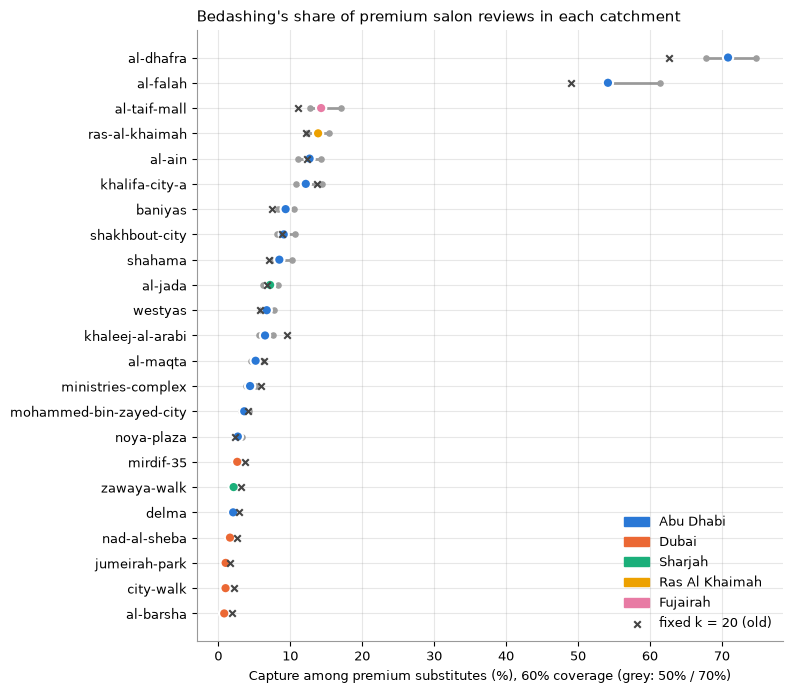

In [5]:
s = t.drop(index=list(EXCLUDE)).sort_values(MID)
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(s))
lo, mid, hi = (s[f"capture_{int(c * 100)}"] * 100 for c in (COV["high"], COV["medium"], COV["low"]))
ax.hlines(y, lo, hi, color=GREY, lw=2, zorder=1)
ax.scatter(mid, y, s=55, color=[COLOR[e] for e in s.emirate], edgecolor="white", lw=1.5, zorder=3)
ax.scatter(lo, y, s=14, color=GREY, zorder=2); ax.scatter(hi, y, s=14, color=GREY, zorder=2)
ax.scatter(s.capture_fixed_k20 * 100, y, s=22, marker="x", color="#444", zorder=4, label="fixed k = 20 (old)")
ax.set_yticks(y, s.index)
ax.set_xlabel(f"Capture among premium substitutes (%), {int(COV['medium'] * 100)}% coverage (grey: 50% / 70%)")
ax.set_title("Bedashing's share of premium salon reviews in each catchment", loc="left")
ax.legend(handles=[Patch(color=COLOR[e], label=e) for e in EMIRATES] + ax.get_legend_handles_labels()[0][-1:],
          frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 6. Why coverage, not a fixed k: what 20 salons represent in each catchment
The share of all candidate reviews held by the top 20 premium salons, against the number of premium
salons in the catchment. With a fixed k this varied from 22% to 66%; under the coverage rule every
catchment's substitutes hold the same 60% of its premium reviews.

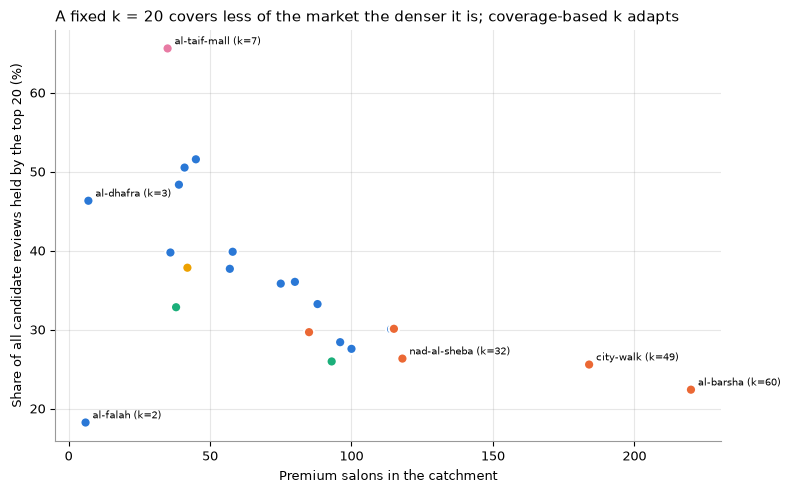

In [6]:
cover20 = {b: sum(s["review_count"] for s in premium.get(b, [])[:20]) / max(1, sum(c["review_count"] for c in by_lounge.get(b, [])))
           for b in branches.index}
d = t.drop(index=list(EXCLUDE)).assign(cover20=pd.Series(cover20), premium=[len(premium.get(b, [])) for b in t.drop(index=list(EXCLUDE)).index])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(d.premium, d.cover20 * 100, s=55, color=[COLOR[e] for e in d.emirate], edgecolor="white", lw=1.5, zorder=3)
for b, r_ in d.iterrows():
    if r_.premium >= 118 or r_.cover20 > 0.55 or r_.premium < 10:
        ax.annotate(f"{b} (k={int(r_.k)})", (r_.premium, r_.cover20 * 100), xytext=(5, 3), textcoords="offset points", fontsize=7)
ax.set_xlabel("Premium salons in the catchment")
ax.set_ylabel("Share of all candidate reviews held by the top 20 (%)")
ax.set_title("A fixed k = 20 covers less of the market the denser it is; coverage-based k adapts", loc="left")
plt.tight_layout(); plt.show()

## 7. Who Bedashing competes with

In [7]:
def top_names(b, n=8):
    subs = premium.get(b, [])[:int(t.loc[b, "k"])]
    return f"k = {len(subs)}: " + ", ".join(f"{s['name'][:28]} ({int(s['review_count'])})" for s in subs[:n])
for b in ["al-barsha", "city-walk", "mirdif-35", "khalifa-city-a", "al-ain", "al-dhafra"]:
    print(f"{b} ({int(branches.loc[b, 'review_count'])} reviews): {top_names(b)}\n")

al-barsha (753 reviews): k = 60: It's Beauty (3219), Ivy The Palm Beauty & Bubble (2994), Its Beauty Ladies Salon – In (2868), Ivy Beauty & Bubbles Hotel I (2738), Its Beauty Ladies Salon – Bu (2666), BROWZ (2573), Ivy Beauty & Bubbles Hub Mar (2346), Elata Beauty Salon - Jumeira (2205)

city-walk (857 reviews): k = 49: Ivy Beauty & Bubbles Sherato (4487), Ivy Beauty & Bubbles Hotel I (2738), Its Beauty Ladies Salon – Bu (2666), BROWZ (2573), Ashtamudi Ladies Salon BurJu (2406), Ivy Beauty & Bubbles Hub Mar (2346), Hadi beauty Salon (2247), Elata Beauty Salon - Jumeira (2205)

mirdif-35 (817 reviews): k = 23: Ashtamudi Ladies Beauty Salo (2025), مركز حلا الشام للتجميل - ند  (1868), Beauty Room Salon & Spa (1587), Juice Salon Mirdif (1559), Grand Flora Beauty Salon & S (1362), Salon Afrina Beauty & Henna  (1333), Sisters Beauty Lounge Hair S (1149), CARE SECRETS THERAPY CENTER  (1024)

khalifa-city-a (2465 reviews): k = 20: hair and nail beauty salon (2040), Bedashing Beauty Lounge Al M

## 8. Findings

**The search is sound for the big competitors, thin on the tail.** On the fully swept Al Barsha
tile our 1.8 km popularity circles rank 8/10, 17/20 and 25/30 of the true top premium salons
correctly, but find only **66% of the premium reviews** (54 of 137 premium salons: the smaller ones
are missed where Google's 20-result cap bites). That 66% is `search_recall`, an estimate to replace
if a full sweep is ever run, and an upper bound because the sweep itself missed salons. The cap
bit hardest in city-walk and zawaya-walk (76% of circles full), then mirdif-35, al-barsha and
nad-al-sheba (53-61%); recall multipliers run from 1.03 (al-dhafra) to 1.39.

**Coverage-based k adapts to density.** Reaching 60% of each catchment's premium reviews takes 60
substitutes around al-barsha and 49 around city-walk, 18-32 elsewhere in Dubai, Sharjah and central Abu Dhabi,
7-16 in Al Ain, RAK and Fujairah, and 2-3 in Al Dhafra and Al Falah.

**Capture (60% coverage, recall-corrected):**
- **Highest where Bedashing leads its set:** al-taif-mall 14% (Fujairah), ras-al-khaimah 14%, al-ain
  13% (rank 1), khalifa-city-a 12% (rank 1; 4 other Bedashing lounges among its 20 substitutes).
- **Lowest in dense Dubai:** al-barsha 0.8%, city-walk 1.0%, jumeirah-park 1.0%, nad-al-sheba 1.6%,
  mirdif-35 2.6%, plus zawaya-walk 2.1% and delma 2.1%. Bedashing ranks 24th-42nd among its own
  substitutes in al-barsha, city-walk, jumeirah-park and nad-al-sheba: the premium end there is led
  by salons and chains with 2,000-4,500 reviews (Ivy Beauty & Bubbles, It's Beauty, BROWZ, Elata).
- **Unreliable: al-dhafra 71%, al-falah 54%.** Only 6-7 premium salons each, so capture is a share
  of a tiny pool (flagged `thin_premium_market`).

**Versus the old fixed k = 20:** dense Dubai roughly halves (al-barsha 1.9% → 0.8%, city-walk 2.2%
→ 1.0%), because 60% coverage needs 49-60 substitutes there and the recall correction adds ~30-40%;
thin markets rise (al-taif-mall 11% → 14%). The ranking of lounges is broadly unchanged; the gap
between thin and dense markets widens, which is what the bias called for.

**Sensitivity:** 50% vs 70% coverage moves dense-Dubai capture by under half a point and the
strongest lounges by 3-4 points (al-taif-mall 17% → 13%).

**Estimated customers (capture x women 15+ in the catchment)** are an order of magnitude only:
~1.8-2.6k for al-barsha, city-walk and jumeirah-park, 4-6k for nad-al-sheba and mirdif-35, ~10-13k for al-ain,
khalifa-city-a, shakhbout-city and baniyas.
Reviews per customer differ between salons, and review counts are lifetime totals.

## 9. Examples
Two lounges: a dense market where Bedashing is small (**al-barsha**) and one where it leads its
premium set (**khalifa-city-a**). The map shows the 15-min catchment, the substitutes at 60%
coverage (orange, sized by reviews; other Bedashing lounges in blue) and the other candidates
(grey). Below each map: the substitutes, and the men-only salons nearest the lounge that were
excluded.

In [8]:
from IPython.display import Markdown, display
from shapely.geometry import mapping
from scripts.spot_maps import points, shapes, show
from src.features.lounges import haversine_km

for bid in ["al-barsha", "khalifa-city-a"]:
    r = branches.loc[bid]
    k = int(t.loc[bid, "k"])
    subs = premium.get(bid, [])[:k]
    ids = {s["place_id"] for s in subs}
    others = [c for c in by_lounge[bid] if c["place_id"] not in ids]
    poly = make_valid(shape(polygons(r.lat, r.lng, ranges_minutes(L), A["isochrone_depart_at"])[L["medium"]]))
    display(Markdown(f"### {bid}: {int(r.review_count):,} reviews, capture {t.loc[bid, MID]:.1%} at {int(COV['medium'] * 100)}% coverage "
                     f"(k = {k}, recall multiplier {t.loc[bid, 'multiplier']:.2f}), rank {int(t.loc[bid, 'rank'])} of its set; "
                     f"{len(by_lounge[bid])} candidates in the catchment"))
    layers = [shapes([{"type": "Feature", "geometry": mapping(poly), "properties": {"label": "15-min catchment"}}],
                     fill=(42, 120, 214, 20)),
              points([{"lat": c["lat"], "lng": c["lng"], "label": f"{c['name']} ({int(c['review_count'])})", "r": 60} for c in others], (160, 160, 160)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 60 + 4 * s["review_count"] ** 0.5,
                       "label": f"{s['name']}: {int(s['review_count'])} reviews, {s['rating']}★, {s['price_level'] or 'no price'}"}
                      for s in subs if not s.get("is_bedashing")], (235, 104, 52)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 60 + 4 * s["review_count"] ** 0.5, "label": f"{s['name']} (Bedashing)"}
                      for s in subs if s.get("is_bedashing")], (42, 120, 214)),
              points([{"lat": r.lat, "lng": r.lng, "label": f"{bid} (this lounge)", "r": 300}], (20, 20, 20))]
    display(show(layers, r.lat, r.lng, zoom=11, height=520))
    display(pd.DataFrame([{"rank": i, "name": s["name"], "reviews": int(s["review_count"]), "rating": s["rating"],
                           "premium because": f"Google price: {s['price_level']}" if s["price_level"] else "popular + rated ≥ 4.3",
                           "km from lounge": round(haversine_km(r.lat, r.lng, s["lat"], s["lng"]), 1)}
                          for i, s in enumerate(subs, start=1)]))
    men = salons[(salons.excluded_reason == "men-only")].copy()
    men["km"] = [haversine_km(r.lat, r.lng, la, ln) for la, ln in zip(men.lat, men.lng)]
    display(Markdown("**Nearest excluded as men-only:** " + "; ".join(
        f"{n} ({km:.1f} km, {ty or 'no type'})" for n, km, ty in men.nsmallest(6, "km")[["name", "km", "primary_type"]].values)))

### al-barsha: 753 reviews, capture 0.8% at 60% coverage (k = 60, recall multiplier 1.30), rank 42 of its set; 507 candidates in the catchment

,rank,name,reviews,rating,premium because,km from lounge
0,1,It's Beauty,3219,4.9,Google price: very_expensive,7.7
1,2,Ivy The Palm Beauty & Bubbles,2994,4.8,Google price: very_expensive,7.1
2,3,Its Beauty Ladies Salon – Internet City,2868,4.8,Google price: very_expensive,4.4
3,4,Ivy Beauty & Bubbles Hotel Indigo Business Bay,2738,4.8,Google price: very_expensive,11.4
4,5,Its Beauty Ladies Salon – Business Bay,2666,4.9,Google price: very_expensive,9.3
5,6,BROWZ,2573,4.8,popular + rated ≥ 4.3,2.8
6,7,Ivy Beauty & Bubbles Hub Marquise Square,2346,4.9,Google price: very_expensive,10.0
7,8,"Elata Beauty Salon - Jumeirah 3, Dubai",2205,4.8,popular + rated ≥ 4.3,8.0
8,9,Nboutique Beauty on Demand,1809,4.7,Google price: expensive,8.0
9,10,It's Beauty,1750,4.8,Google price: very_expensive,12.9


**Nearest excluded as men-only:** Golden Style Gents Saloon (0.8 km, barber_shop); The Barbershop & Cafe Al Qouz (0.8 km, barber_shop); LVLS (1.1 km, barber_shop); Gents Mania Saloon & Spa جنتس مينيا صالون و سبا (1.1 km, barber_shop); صالون نجمة البرشاء (1.3 km, barber_shop); Sama Al Sham Gents Salon (1.4 km, beauty_salon)

### khalifa-city-a: 2,465 reviews, capture 12.2% at 60% coverage (k = 20, recall multiplier 1.14), rank 1 of its set; 243 candidates in the catchment

,rank,name,reviews,rating,premium because,km from lounge
0,1,hair and nail beauty salon,2040,4.7,popular + rated ≥ 4.3,4.1
1,2,Bedashing Beauty Lounge Al Maqta,1295,4.6,popular + rated ≥ 4.3,11.1
2,3,Bedashing Beauty Lounge Ministries Complex,1217,4.9,popular + rated ≥ 4.3,13.6
3,4,Mikas Beauty Salon,1208,4.9,popular + rated ≥ 4.3,15.8
4,5,Le Beautique Spa Center,926,4.4,Google price: expensive,10.0
5,6,"Tara Rose Salons - Khalifa City A, Abu Dhabi",918,4.8,popular + rated ≥ 4.3,3.3
6,7,Boho Salon,835,4.8,popular + rated ≥ 4.3,7.1
7,8,Its Beauty Ladies Salon – Sail Tower,736,4.8,Google price: very_expensive,2.5
8,9,Bedashing Beauty Lounge West Yas,733,4.6,Google price: very_expensive,6.1
9,10,The H Ladies Beauty Salon,660,4.5,Google price: expensive,2.2


**Nearest excluded as men-only:** حلاق المصرينbarbershop Egyptian (1.0 km, hair_salon); The Dark Room Barbershop (1.0 km, barber_shop); PICASSO TOUCH SALON FOR GENTS – Al Raha (1.1 km, barber_shop); Salon Les Messieurs Barbershop صالون لي مسيو للرجال (1.1 km, barber_shop); TIME SQUARE Barbershop - Al Bandar (1.1 km, barber_shop); Fair and Handsome Gents Salon (1.3 km, hair_salon)